This script works on addressing need to get estimates of % O3 produced versus imported

In [1]:
import os
import glob
import fnmatch

import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point, Polygon

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt # Core library for plotting
import matplotlib.cm as cm # To use different colormaps
import cartopy.crs as ccrs # For map projection
import seaborn as sns # boxplot


/home/taoma528/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# !pip install geopandas


In [3]:
import sys
sys.path.insert(0,'/home/taoma528/Scripts/CESM_analysis/functions/')

from Plot_2D import Plot_2D # To draw a map

SCRIP_CONUS = '/home/taoma528/Scripts/CESM_analysis/functions/ne0CONUS_ne30x8_np4_SCRIP.nc'
SCRIP_ne30 = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons.nc'

In [4]:
def molecules_to_kg_per_m2_per_s(molecules_per_cm2_per_s, molecular_weight):
    """
        Read in emissions data in [molecules cm-2 s-1], and molecular_weight in [g/mole]
        Return emissions in [kg m-2 s-1]    
    """
    # Constants
    avogadro_number = 6.022e23  # molecules per mole
    m2_to_cm2 = 1e4  # square meters to square centimeters 
    kg_to_g = 1e3

    # Convert 
    kg_per_m2_per_s = molecules_per_cm2_per_s*(1/avogadro_number)*molecular_weight*(1/kg_to_g)*(m2_to_cm2)

    return kg_per_m2_per_s

# # Example usage
# molecules_per_cm2_per_s = 1  # for example, 1e18 molecules per cm^2 per second
# molecular_weight = 30  # molecular weight of water in g/mol

# result = molecules_to_kg_per_m2_per_s(molecules_per_cm2_per_s, molecular_weight)
# print("Result:", result, "kg/m^2/s")


setunit = r'$kg$ $m^{-2}s^{-1}$'

In [5]:
### Geo information for boundaries
import geopandas as gpd

# Path to the shapefile (adjust if the file is inside a folder)
shapefile_path = '/home/taoma528/HelpfulFiles/world-administrative-boundaries/world-administrative-boundaries.shp'

# Read shapefile directly
gdf = gpd.read_file(shapefile_path)

# # Preview
# print(gdf.columns)
# print(gdf.head())

# Adjust based on the actual column names (use print(gdf.columns) to confirm)
us_boundary = gdf[(gdf['status'] == 'Member State')&(gdf['name'] == 'United States of America')]  # or 'USA', depending on the file

# Create a GeoDataFrame
us_gdf = gpd.GeoDataFrame(us_boundary, geometry='geometry')

from shapely.geometry import Point
import numpy as np
import xarray as xr


# Remove emissions over CONUS Box-land

In [43]:
### Read in NEI emissions data
CAMS_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANTv5.1/ne30np4/Y2022_copied2021_c20241011/'

CONUSlandMasked_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANTv5.1/ne30np4/Y2022_CONUSlandMasked_copied2021_c20250526/'
# NYCMasked_diri = '/net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/NYCMasked_MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8_JulyMean/' # where to put the Masked files


In [11]:
# Search for files that match the pattern

import glob
import os

# Directory where files are stored
# CAMS_diri = '/path/to/your/files'  # Make sure this is correctly defined

# Updated pattern with wildcard
pattern = os.path.join(CAMS_diri, 'CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_*.nc')

# Get list of matching files in full path
CAMS_v51_file_list = glob.glob(pattern)
# print(CAMS_v51_file_list)

# Extract only the filenames
CAMS_v51_file_names = [os.path.basename(f) for f in CAMS_v51_file_list]

print(CAMS_v51_file_names[:3])


['CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_HCN_c20210423_modified.nc', 'CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_so4_a2_res_trs_c20210423_modified.nc', 'CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_C3H8_c20210423_modified.nc']


In [10]:
# CAMS_v51_file_names[0].split('_')[4]

spc_ls = []
for spcIdx in range(len(CAMS_v51_file_names)):
    spc_name = CAMS_v51_file_names[spcIdx].split('_')[4]
    spc_ls.append(spc_name)

In [15]:
import re
# Extract species name between 'ne30np4_' and '_c20210423'
species_names = [
    re.search(r'ne30np4_(.+?)_c20210423', f).group(1)
    for f in CAMS_v51_file_names
]
species_names = sorted(species_names)
print(species_names)

['BENZENE', 'BIGALK', 'BIGENE', 'C2H2', 'C2H4', 'C2H5OH', 'C2H6', 'C3H6', 'C3H8', 'CH2O', 'CH3CHO', 'CH3CN', 'CH3COCH3', 'CH3COOH', 'CH3OH', 'CO', 'HCN', 'HCOOH', 'HONO', 'ISOP', 'IVOC', 'MEK', 'MTERP', 'NH3', 'NO', 'SO2', 'SVOC', 'TOLUENE', 'XYLENES', 'bc_a4', 'num_bc_a4', 'num_pom_a4', 'num_so4_a1_ag', 'num_so4_a1_ene_vertical', 'num_so4_a1_ship_fef', 'num_so4_a2_res_trs', 'pom_a4', 'so4_a1_ag_ship_fef', 'so4_a1_ene_vertical', 'so4_a2_res_trs']


In [16]:
# CAMS_v51_file_list

In [ ]:
spc_fileOUTpath = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'

In [20]:
Abs_rangeMax_dic = {'NO':7e-11,
                  'CO':5e-10,
                  'SO2':3e-11, 
                  'bc_a4':3e-12,
                  'NH3':2e-11,
                  'C2H2':2e-12, 
                  'C2H4':5e-12, # ethene
                  'C2H5OH':5e-11,
                  'C2H6':6e-12, # ethane
                  'C3H6':2e-11, 
                  'C3H8':2e-12, 
                  'CH3OH':2e-12,
                  'CH3CHO':2e-12, # 
                  'CH3COCH3':2e-12, 
                  'MEK':2e-12,
                    
                # Second panel
                  'BENZENE':3e-12, 
                  'TOLUENE':7e-12,
                  'BIGENE':4e-12,   
                  'MTERP':5e-13, 
                  'ISOP':8e-14, 
                  'CH2O':3e-12, # formaldehyde
                  'SVOC':6e-12,
                   }

## Note that the magnitude for some VOC species is much lower compared to their biogenic emissions
# MTERP: 4.90e-13 | 2.14e-13 (anthrop) compared to 
# ISOP: 8.37e-14 | 7.34e-14 (anthrop) compared to 

In [21]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # Change to a font that supports the superscript characters

def get_superscript(magnitude):
    return r'$10^{' + str(magnitude) + '}$'

### Remove for a list of species files

In [31]:
# ### Create the Masked array and save to nc file | use NO
# spc = 'NO'
# spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'
# # Open Xarray dataset
# spci_ds = xr.open_dataset(spc_fileINpath)

# # MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
# lat = spci_ds['lat'].values
# lon = spci_ds['lon'].values
# Adjustedlons = np.where(lon >= 180, lon - 360, lon)
# # Create a DataArray for the adjusted lon
# Adjustedlons_da = xr.DataArray(
#                                 Adjustedlons,  
#                                 dims=('ncol'),
#                                 coords={'ncol': spci_ds.ncol.values} 
#                                 )

# # Add the DataArray back to the dataset
# spci_ds['Adjustedlons'] = Adjustedlons_da

# ### To process for all months for the given period (reduce the size of processed dataset)
# Timei = '2022-07-31T00:00:00.000000000'
# MonthiMean_ds = spci_ds.sel(time=Timei)
# latitudes = MonthiMean_ds.lat.values
# longitudes = MonthiMean_ds.Adjustedlons.values
# # MonthiMean_ds

# # Step 1: Define CONUS bounding box
# lon_lefti = -66.95   # Eastern edge
# lon_righti = -125.0  # Western edge
# lat_boti = 24.4      # Southern edge
# lat_upi = 49.5       # Northern edge

# # Step 2: Create a combined mask
# mask = np.zeros(len(lat), dtype=bool)

# for geom in gdf['geometry']:
#     for i in range(len(lat)):
#         lon = Adjustedlons[i]
#         lati = lat[i]
#         point = Point(lon, lati)

#         # Only mask if inside CONUS bounding box and also within the geometry
#         in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
#         if in_box and geom.contains(point):
#             mask[i] = True

# # Step 3: Convert to xarray mask
# mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# # Step 4: Apply the mask to remove CONUS land pixels
# masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
# # sum_masked = masked_ds['sum']

# ### Can probably save this masked array to use later 
# maskfilePath = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse.nc'
# # Save mask_da to a NetCDF file
# mask_da.to_netcdf(maskfilePath)
# print('Save to:', maskfilePath)

In [45]:
ne30maskfilePath = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse.nc'
# Read the saved NetCDF file
mask_da_loaded = xr.open_dataarray(ne30maskfilePath)

In [42]:
# masked_ds = MonthiMean_ds.where(~mask_da_loaded, drop=False)
# masked_ds

In [71]:
targetspc_ls = ['ISOP', 'NO']
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2022-11-30T00:00:00.000000000'

for spc in targetspc_ls:
    spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'
    
    # Open Xarray dataset
    spci_ds = xr.open_dataset(spc_fileINpath)

    # MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
    lat = spci_ds['lat'].values
    lon = spci_ds['lon'].values
    Adjustedlons = np.where(lon >= 180, lon - 360, lon)
    # Create a DataArray for the adjusted lon
    Adjustedlons_da = xr.DataArray(
                                    Adjustedlons,  
                                    dims=('ncol'),
                                    coords={'ncol': spci_ds.ncol.values} 
                                    )

    # Add the DataArray back to the dataset
    spci_ds['Adjustedlons'] = Adjustedlons_da
    
    ### Use the mask read in to remove pixels over CONUS-land, need to use zero instead of nan
    sum_masked = spci_ds['sum'].where(~mask_da_loaded, other=0)

    spci_ds['sum'] = sum_masked

    # Remove the 'Adjustedlons' variable from the dataset
    spci_ds = spci_ds.drop_vars('Adjustedlons')
    
    ### Save masked to the corresponding file
    spc_fileOUTpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'
    spci_ds.to_netcdf(spc_fileOUTpath)
    print('Save to:',spc_fileOUTpath)

Save to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANTv5.1/ne30np4/Y2022_CONUSlandMasked_copied2021_c20250526/CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_ISOP_c20210423_modified.nc
Save to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANTv5.1/ne30np4/Y2022_CONUSlandMasked_copied2021_c20250526/CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_NO_c20210423_modified.nc


In [75]:
masked_ds

<xarray.Dataset> Size: 53MB
Dimensions:    (time: 264, ncol: 48602)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2000-12-31 2001-01-31 ... 2022-11-30
  * ncol       (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04 4.86e+04
Data variables:
    year       (time) int32 1kB ...
    month_day  (time) int32 1kB ...
    date       (time) int32 1kB ...
    area       (ncol) float64 389kB ...
    lat        (ncol) float64 389kB ...
    lon        (ncol) float64 389kB ...
    sum        (time, ncol) float32 51MB ...
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

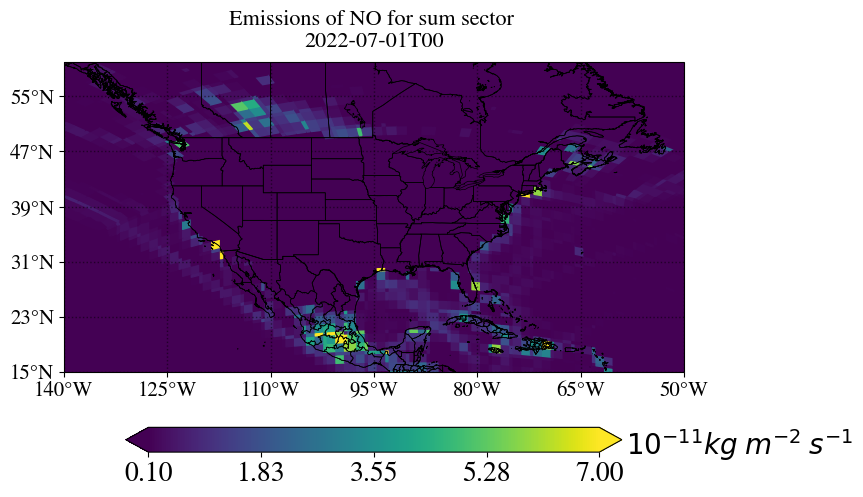

In [76]:
testfile = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANTv5.1/ne30np4/Y2022_CONUSlandMasked_copied2021_c20250526/CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_NO_c20210423_modified.nc'
test_ds = xr.open_dataset(testfile)

### Plotting
# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

# Quick plot to check
Timei = '2022-07-01T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne30)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = test_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = masked_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, 
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

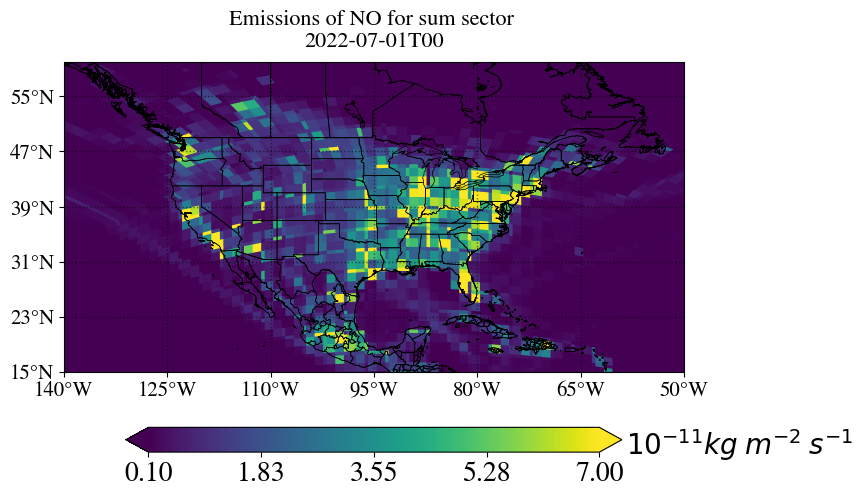

In [77]:
testfile = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_NO_c20210423_modified.nc'
test_ds = xr.open_dataset(testfile)

### Plotting
# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

# Quick plot to check
Timei = '2022-07-01T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne30)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = test_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = masked_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, 
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

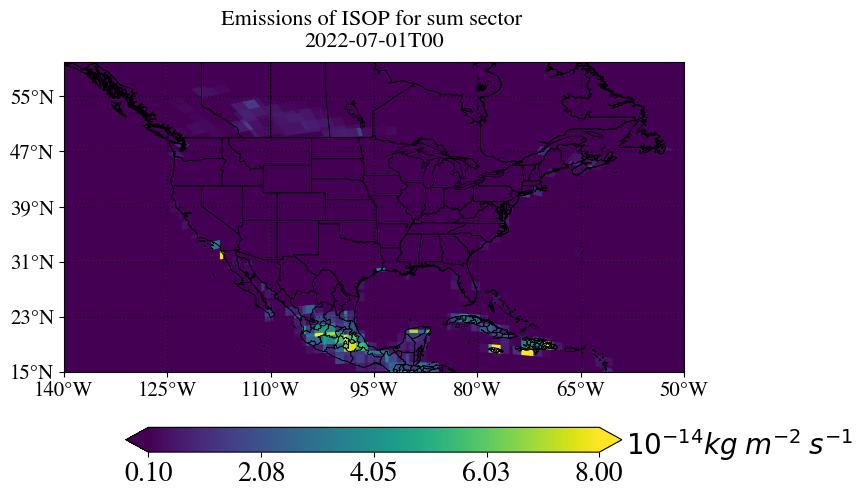

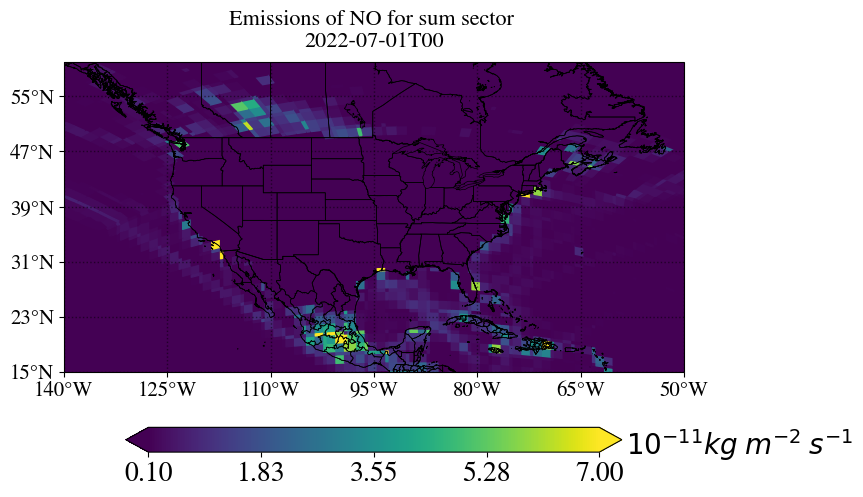

In [74]:
## Read back
for spc in targetspc_ls:
    spc_maskedINpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'
    masked_ds = xr.open_dataset(spc_maskedINpath)

    ### Plotting
    # get rangeMax
    rangeMax = Abs_rangeMax_dic[spc]

    ### Accounting for scientific notation
    # Get the magnitude in scientific notation, adjust for e-
    magnitude = int(np.floor(np.log10(abs(rangeMax))))
    # Format the magnitude as a superscript
    formatted_magnitude = get_superscript(str(magnitude))
    modified_rangeMax = rangeMax*(1/(10)**magnitude)
    
    # Quick plot to check
    Timei = '2022-07-01T00:00:00.000000000'

    setmap = 'viridis'

    """ds_mappedMUSICA (regridded to ne30)"""
    PlotRegion = 'CONUS'

    # scalefactor = 1e-11
    # formatted_label = f"{scalefactor:.0e}" 

    Plot_ar = masked_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

    vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
    Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
    longname = masked_ds['sum'].long_name
    rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

    ### Which map
    fig = plt.figure( figsize=(8,6) ) 
    # - ne30x8 regional refinement over CONUS|
    ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
    if PlotRegion=="CONUS":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, lon_range=[-140,-50], lat_range=[15,60],
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
    elif PlotRegion=="Global":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, 
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

    plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [69]:
masked_ds.time.values

array(['2021-11-30T00:00:00.000000000', '2021-12-31T00:00:00.000000000',
       '2022-01-31T00:00:00.000000000', '2022-02-28T00:00:00.000000000',
       '2022-03-31T00:00:00.000000000', '2022-04-30T00:00:00.000000000',
       '2022-05-31T00:00:00.000000000', '2022-06-30T00:00:00.000000000',
       '2022-07-31T00:00:00.000000000', '2022-08-31T00:00:00.000000000',
       '2022-09-30T00:00:00.000000000', '2022-10-31T00:00:00.000000000',
       '2022-11-30T00:00:00.000000000'], dtype='datetime64[ns]')

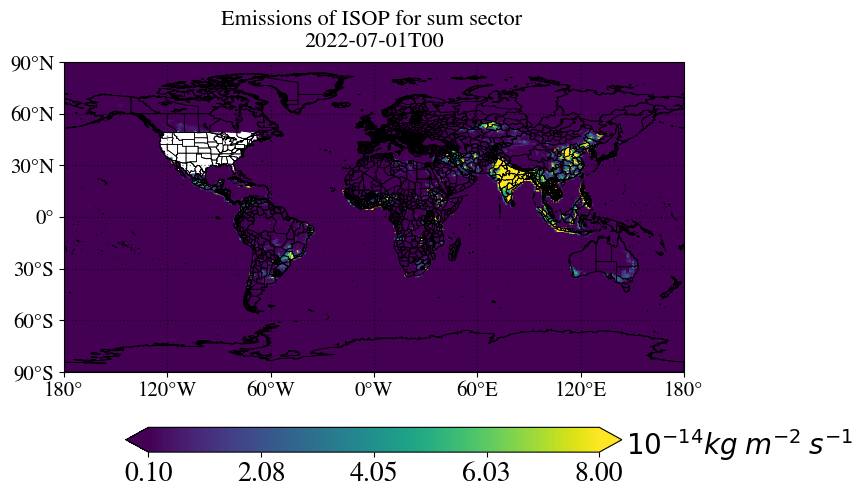

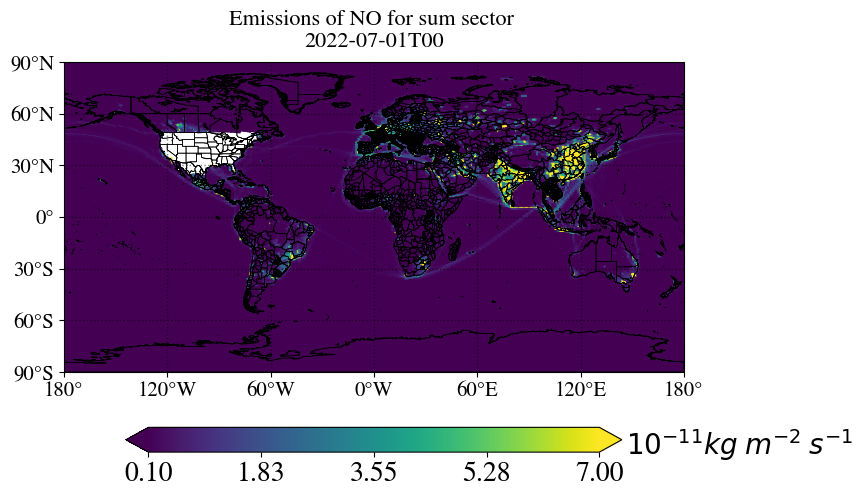

In [67]:
## Read back
for spc in targetspc_ls:
    spc_maskedINpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'
    masked_ds = xr.open_dataset(spc_maskedINpath)

    ### Plotting
    # get rangeMax
    rangeMax = Abs_rangeMax_dic[spc]

    ### Accounting for scientific notation
    # Get the magnitude in scientific notation, adjust for e-
    magnitude = int(np.floor(np.log10(abs(rangeMax))))
    # Format the magnitude as a superscript
    formatted_magnitude = get_superscript(str(magnitude))
    modified_rangeMax = rangeMax*(1/(10)**magnitude)
    
    # Quick plot to check
    Timei = '2022-07-01T00:00:00.000000000'

    setmap = 'viridis'

    """ds_mappedMUSICA (regridded to ne30)"""
    PlotRegion = 'Global'

    # scalefactor = 1e-11
    # formatted_label = f"{scalefactor:.0e}" 

    Plot_ar = masked_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

    vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
    Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
    longname = masked_ds['sum'].long_name
    rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

    ### Which map
    fig = plt.figure( figsize=(8,6) ) 
    # - ne30x8 regional refinement over CONUS|
    ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
    if PlotRegion=="CONUS":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, lon_range=[-140,-50], lat_range=[15,60],
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
    elif PlotRegion=="Global":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, 
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

    plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

### Test for Nitric Oxide Emissions (NO) | 2-D and only contains 'sum' sector

In [22]:
spc = 'NO'
spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'

# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

In [23]:
# Open Xarray dataset
spci_ds = xr.open_dataset(spc_fileINpath)

# MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
lat = spci_ds['lat'].values
lon = spci_ds['lon'].values
Adjustedlons = np.where(lon >= 180, lon - 360, lon)
# Create a DataArray for the adjusted lon
Adjustedlons_da = xr.DataArray(
                                Adjustedlons,  
                                dims=('ncol'),
                                coords={'ncol': spci_ds.ncol.values} 
                                )

# Add the DataArray back to the dataset
spci_ds['Adjustedlons'] = Adjustedlons_da

In [10]:
spci_ds

<xarray.Dataset> Size: 53MB
Dimensions:       (time: 264, ncol: 48602)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2000-12-31 2001-01-31 ... 2022-11-30
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (time) int32 1kB ...
    month_day     (time) int32 1kB ...
    date          (time) int32 1kB ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (time, ncol) float32 51MB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


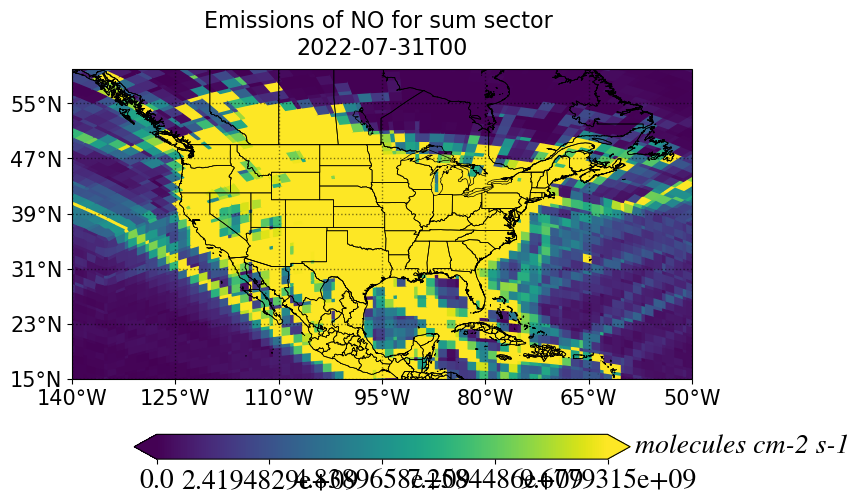

In [11]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


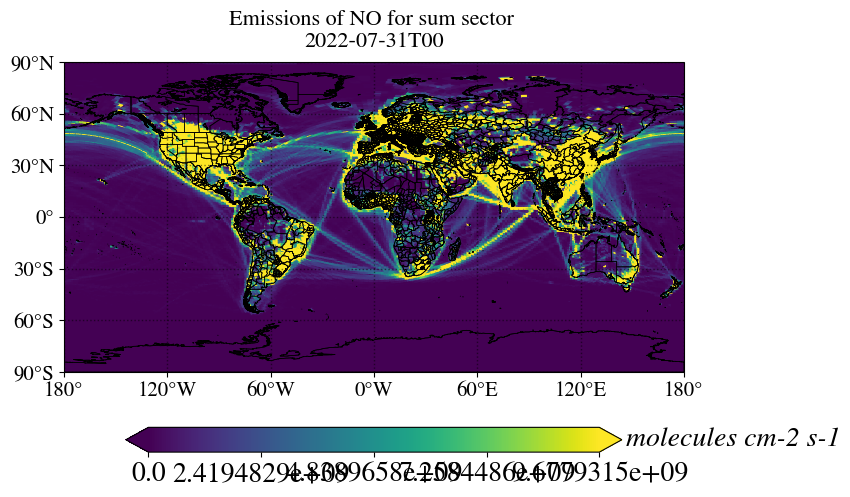

In [12]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 
MonthiMean_da = spci_ds.sel(time=Timei)['sum']

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [ ]:
spci_ds.time.values

In [27]:
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2022-11-30T00:00:00.000000000'


seltimeMean_ds = spci_ds.sel(time=slice(timeslice_start,timeslice_end))
latitudes = seltimeMean_ds.lat.values
longitudes = seltimeMean_ds.Adjustedlons.values
# seltimeMean_ds

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = seltimeMean_ds.where(~mask_da, drop=False)
sum_masked = masked_ds['sum']


In [32]:
### Can probably save this masked array to use later 
savefilePath = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse.nc'
# Save mask_da to a NetCDF file
mask_da.to_netcdf(savefilePath)

In [33]:
mask_da

<xarray.DataArray (ncol: 48602)> Size: 49kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * ncol     (ncol) float64 389kB 0.0 1.0 2.0 3.0 ... 4.86e+04 4.86e+04 4.86e+04

In [34]:
masked_ds = seltimeMean_ds.where(~mask_da, drop=False)
masked_ds

<xarray.Dataset> Size: 20MB
Dimensions:       (time: 13, ncol: 48602)
Coordinates:
  * time          (time) datetime64[ns] 104B 2021-11-30 ... 2022-11-30
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (time, ncol) float64 5MB 2.02e+03 2.02e+03 ... 2.021e+03
    month_day     (time, ncol) float64 5MB 1.115e+03 1.115e+03 ... 1.115e+03
    date          (time, ncol) float64 5MB 2.021e+07 2.021e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (time, ncol) float32 3MB 1.089e+09 3.526e+08 ... 7.067e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [ ]:
### To process for all months for the given period (reduce the size of processed dataset)
Timei = '2022-07-31T00:00:00.000000000'

MonthiMean_ds = spci_ds.sel(time=Timei)
latitudes = MonthiMean_ds.lat.values
longitudes = MonthiMean_ds.Adjustedlons.values
# MonthiMean_ds

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
sum_masked = masked_ds['sum']


In [14]:
### To process for one month
Timei = '2022-07-31T00:00:00.000000000'

MonthiMean_ds = spci_ds.sel(time=Timei)
latitudes = MonthiMean_ds.lat.values
longitudes = MonthiMean_ds.Adjustedlons.values
# MonthiMean_ds

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
sum_masked = masked_ds['sum']


In [15]:
sum_masked

<xarray.DataArray 'sum' (ncol: 48602)> Size: 194kB
array([8.4442291e+08, 1.7281021e+08, 9.2917936e+07, ..., 1.0683996e+10,
       6.6580517e+10, 8.8879596e+09], dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-07-31
  * ncol     (ncol) float64 389kB 0.0 1.0 2.0 3.0 ... 4.86e+04 4.86e+04 4.86e+04
Attributes:
    standard_name:           NO
    long_name:               Emissions of NO for sum sector
    units:                   molecules cm-2 s-1
    molecular_weight:        30.0
    molecular_weight_units:  g mole-1
    sector_name:             Agriculture soils

In [16]:
JulyMeanNEIMerged_vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_CONUS, ax=ax,
                unit=formatted_magnitude,unit_size=30,title_size=40,colortick_size=30,
                 cmin=0.1, cmax=modified_rangeMax

'molecules cm-2 s-1'

In [34]:
molecules_to_kg_per_m2_per_s

<function __main__.molecules_to_kg_per_m2_per_s(molecules_per_cm2_per_s, molecular_weight)>

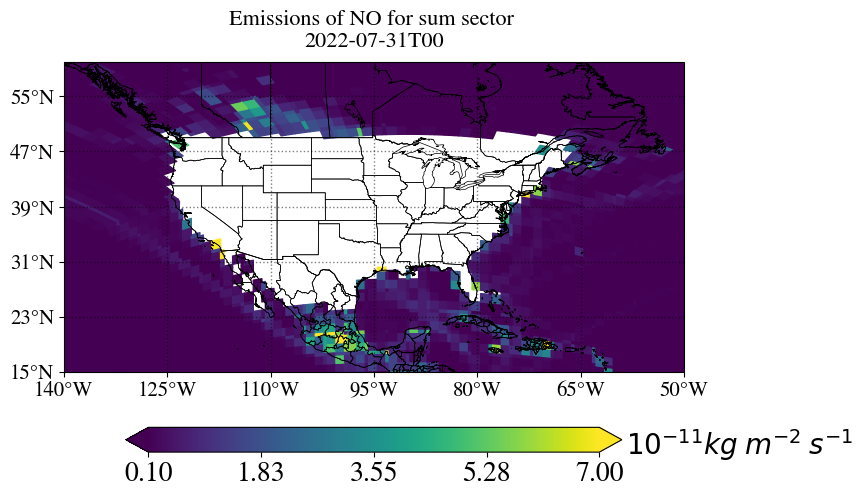

In [42]:
# Quick plot to check

setmap =  'viridis' #'CMRmap_r'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = spci_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            # state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

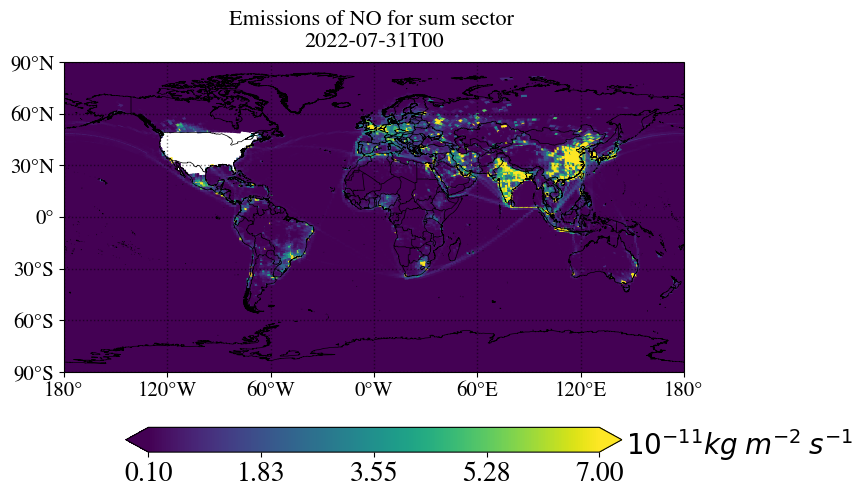

In [43]:
# Quick plot to check

setmap = 'viridis' #'CMRmap_r'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = spci_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            # state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True )   

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

### Trial

In [26]:
MonthiMean_ds = spci_ds.sel(time=Timei)
latitudes = MonthiMean_ds.lat.values
longitudes = MonthiMean_ds.Adjustedlons.values
MonthiMean_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          int32 4B ...
    month_day     int32 4B ...
    date          int32 4B ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [ ]:
### First select over land
import rasterio
from rasterio.features import rasterize
# **Load High-Resolution Land Shapefile**
land_shapefile = "/home/taoma528/HelpfulFiles/ne_10m_land/ne_10m_land.shp"
gdf_land = gpd.read_file(land_shapefile)

# select for land pixel only
# **Define Raster Transform (Corrected)**
transform = rasterio.transform.from_bounds(
    longitudes.min(), latitudes.max(),  # Bottom-left corner
    longitudes.max(), latitudes.min(),  # Top-right corner
    len(longitudes), len(latitudes)     # Grid size
)

# **Rasterize Land Mask (1=Land, 0=Water)**
land_mask = rasterize(
    [(geom, 1) for geom in gdf_land.geometry], 
    out_shape=(len(latitudes), len(longitudes)), 
    transform=transform, 
    fill=0, 
    all_touched=True,  # Ensures land edges are included
    dtype=np.uint8
)

land_mask_xr = xr.DataArray(
    land_mask, 
    dims=["lat", "Adjustedlons"], 
    coords={"lat": MonthiMean_ds["lat"], "Adjustedlons": MonthiMean_ds["Adjustedlons"]}
)

# **Apply Mask to Dataset**
MonthiMean_da_land = MonthiMean_da.where(land_mask_xr)

In [40]:
gdf_land

,featurecla,scalerank,min_zoom,geometry
0,Land,0.0,0.0,"MULTIPOLYGON (((-0.00029 -71.49903, 0.01555 -7..."
1,Land,6.0,5.0,"MULTIPOLYGON (((166.13697 -50.86435, 166.20525..."
2,Land,5.0,3.0,"MULTIPOLYGON (((-78.78897 -33.60906, -78.78038..."
3,Land,6.0,6.0,"MULTIPOLYGON (((163.98512 -20.04762, 163.98609..."
4,Land,5.0,4.0,"MULTIPOLYGON (((134.70737 -6.58904, 134.72006 ..."
5,Land,3.0,2.0,"MULTIPOLYGON (((-80.05989 -2.66277, -80.01452 ..."
6,Land,0.0,1.0,"MULTIPOLYGON (((81.87599 7.09195, 81.87843 7.0..."
7,None,NaN,NaN,"MULTIPOLYGON (((55.018 24.97651, 55.0158 24.97..."
8,Land,1.0,1.5,"MULTIPOLYGON (((134.68979 33.82807, 134.72203 ..."
9,Land,5.0,0.5,"MULTIPOLYGON (((14.76303 68.49486, 14.71746 68..."


In [36]:
### Mask values within the CONUS box (rectangular lat-lon box)
fileregion = 'CONUS_refined'

# Refined lat-lon bounding box for CONUS
lon_lefti = -66.95   # Eastern edge (near Maine)
lon_righti = -125.0  # Western edge (near California)
lat_boti = 24.4      # Southern edge (near southern Florida)
lat_upi = 49.5       # Northern edge (U.S.–Canada border)


# Define the mask for the bounding box
mask_inside = (
    (MonthiMean_ds['Adjustedlons'] >= lon_righti) &
    (MonthiMean_ds['Adjustedlons'] <= lon_lefti) &
    (MonthiMean_ds['lat'] >= lat_boti) &
    (MonthiMean_ds['lat'] <= lat_upi)
)

# Invert the mask to get data OUTSIDE the box
mask_outside = ~mask_inside

# Apply the mask to get data outside the region
outside_region_VCDds = MonthiMean_ds.where(mask_outside)


In [37]:
outside_region_VCDds

<xarray.Dataset> Size: 3MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (ncol) float64 389kB 2.021e+03 2.021e+03 ... 2.021e+03
    month_day     (ncol) float64 389kB 715.0 715.0 715.0 ... 715.0 715.0 715.0
    date          (ncol) float64 389kB 2.022e+07 2.022e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB 8.444e+08 1.728e+08 ... 8.888e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


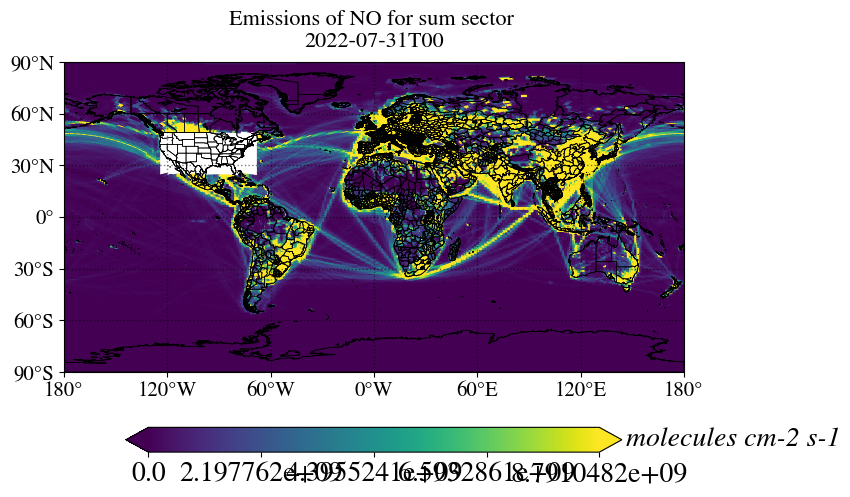

In [38]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = outside_region_VCDds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


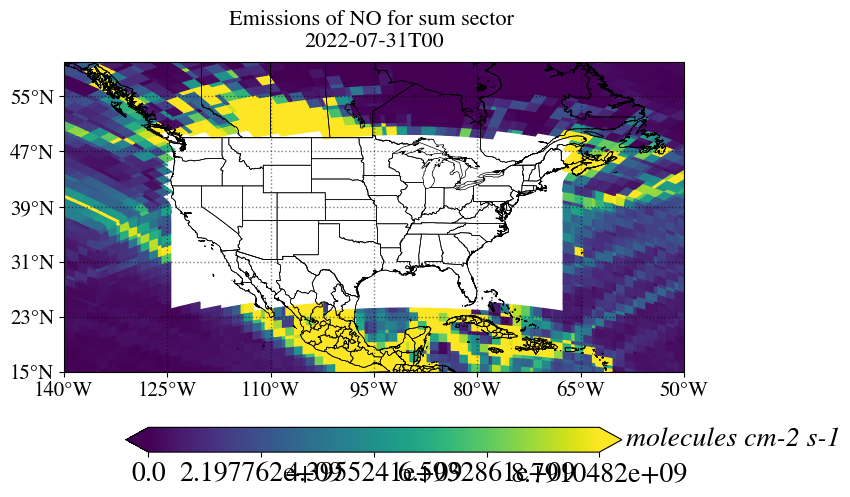

In [39]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = outside_region_VCDds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [ ]:
### To remove only land pixels over the CONUS (keep everythingelse)
# Remove if NOT over water & within the CONUS box 

# Step 1: Pixels outside the CONUS box
mask_outside = ~mask_inside

# Step 2: Pixels inside CONUS box but over water
mask_inside_water = mask_inside & (~land_mask)

# Step 3: Combine the two
final_mask = mask_outside | mask_inside_water

# Step 4: Apply the mask
outside_water_or_outsideCONUS_ds = MonthiMean_ds.where(final_mask)


In [41]:
import geopandas as gpd

# Path to the shapefile (adjust if the file is inside a folder)
shapefile_path = '/home/taoma528/HelpfulFiles/world-administrative-boundaries/world-administrative-boundaries.shp'

# Read shapefile directly
gdf = gpd.read_file(shapefile_path)

# Preview
print(gdf.columns)
print(gdf.head())


Index(['iso3', 'status', 'color_code', 'name', 'continent', 'region',
       'iso_3166_1_', 'french_shor', 'geometry'],
      dtype='object')
   iso3                 status color_code                      name continent  \
0   MNP           US Territory        USA  Northern Mariana Islands   Oceania   
1  None  Sovereignty unsettled        RUS             Kuril Islands      Asia   
2   FRA           Member State        FRA                    France    Europe   
3   SRB           Member State        SRB                    Serbia    Europe   
4   URY           Member State        URY                   Uruguay  Americas   

            region iso_3166_1_               french_shor  \
0       Micronesia          MP  Northern Mariana Islands   
1     Eastern Asia        None             Kuril Islands   
2   Western Europe          FR                    France   
3  Southern Europe          RS                    Serbie   
4    South America          UY                   Uruguay   

          

In [64]:
# Adjust based on the actual column names (use print(gdf.columns) to confirm)
us_boundary = gdf[(gdf['status'] == 'Member State')&(gdf['name'] == 'United States of America')]  # or 'USA', depending on the file

# Create a GeoDataFrame
us_gdf = gpd.GeoDataFrame(us_boundary, geometry='geometry')

In [65]:
us_gdf

,iso3,status,color_code,name,continent,region,iso_3166_1_,french_shor,geometry
88,USA,Member State,USA,United States of America,Americas,Northern America,US,États-Unis d'Amérique,"MULTIPOLYGON (((-155.00558 19.32888, -155.1453..."


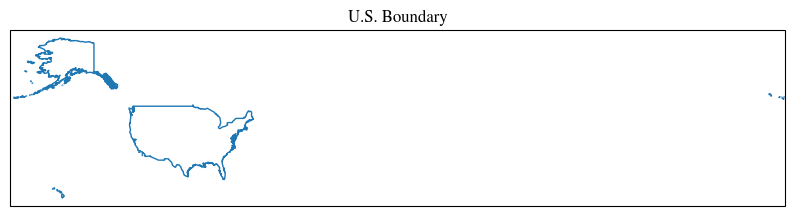

In [66]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
# gdf.plot(ax=ax, color='tab:blue', edgecolor='black')
us_gdf.plot(ax=ax, color='white', edgecolor='tab:blue')

# # Set the extent to the bounding box coordinates
# ax.set_extent([-74.5, -73.5, 40.4, 41], crs=ccrs.PlateCarree())

# Customize the plot (optional)
ax.set_title('U.S. Boundary')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()

In [68]:
# # Create a mask for the dataset
# mask = np.zeros(len(lat), dtype=bool)

# # Iterate over the geometries and update the mask
# points_within_bounds = []
# for geom in gdf['geometry']:
#     for i in range(len(lat)):
#         point = Point(Adjustedlons[i], lat[i])
#         if geom.contains(point):
#             points_within_bounds.append((Adjustedlons[i], lat[i]))
#             mask[i] = True

# # Convert mask to DataArray
# mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# # Apply the mask to the dataset
# masked_ds = MonthiMean_ds.where(mask_da, drop=True)

# # Apply the mask to the 'sum' variable
# # sum_masked = spci_ds['sum'].where(~mask_da, other=np.nan)
# sum_masked = spci_ds['sum'].where(~mask_da, other=0)

In [69]:
from shapely.geometry import Point
import numpy as np
import xarray as xr

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False) # do not drop to keep the same size

# Optionally apply it to just one variable
sum_masked = masked_ds['sum']


In [74]:
# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
sum_masked = masked_ds['sum']

In [73]:
MonthiMean_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          int32 4B ...
    month_day     int32 4B ...
    date          int32 4B ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [75]:
masked_ds

<xarray.Dataset> Size: 3MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (ncol) float64 389kB 2.021e+03 2.021e+03 ... 2.021e+03
    month_day     (ncol) float64 389kB 715.0 715.0 715.0 ... 715.0 715.0 715.0
    date          (ncol) float64 389kB 2.022e+07 2.022e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB 8.444e+08 1.728e+08 ... 8.888e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


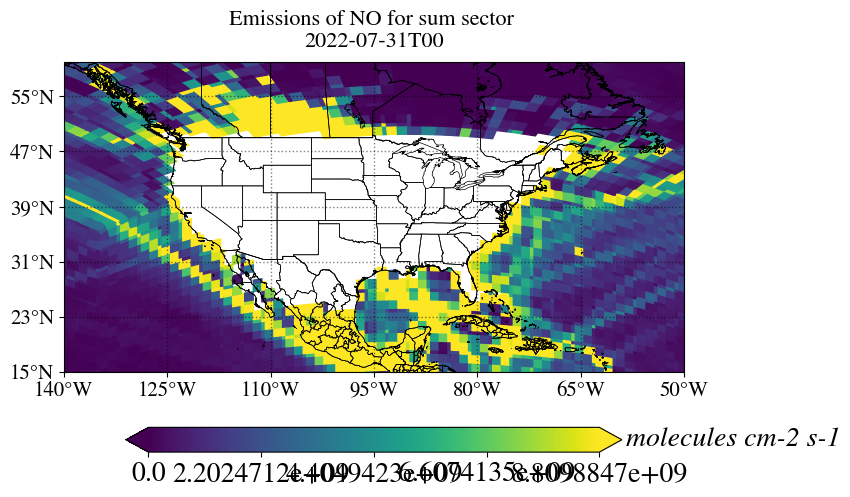

In [77]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


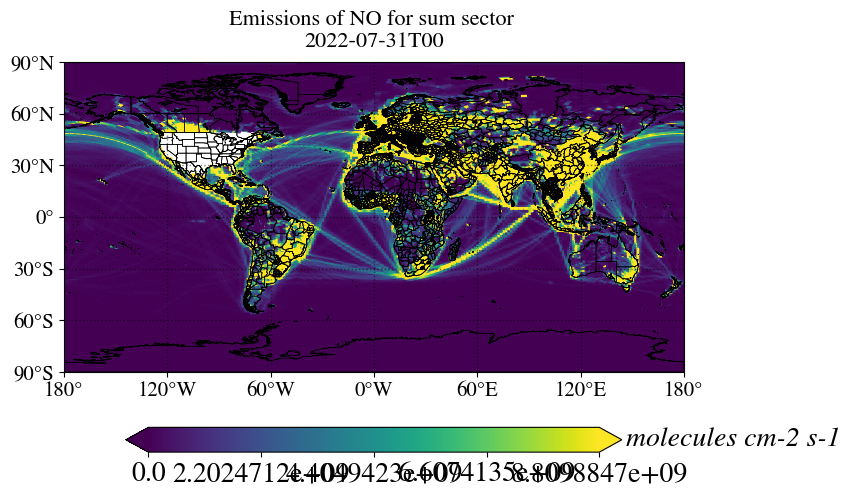

In [79]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

### Continue to process for all target files

In [ ]:
# get a list of species name I have updated 
MappedSpecies_dir = hourlyNEI_diri
DateOfModify = 'c20231113' #'c20231218';'c20231113'

# Search for files that match the pattern
pattern = '*NEI2017Merged_20181MJuly_CAMSv5.1*'+DateOfModify+'*'
Out_file_list = [file for file in glob.glob(os.path.join(MappedSpecies_dir, pattern)) if fnmatch.fnmatch(os.path.basename(file), pattern)]


In [12]:
len(Out_file_list)

updated_spcs = []

for fileidx in range(len(Out_file_list)):
    filename = Out_file_list[fileidx].split('/')[-1]
    # Find the starting and ending indexes for the species name
    start_index = filename.find('ne0CONUSne30x8_') + len('ne0CONUSne30x8_')
    end_index = filename.find(DateOfModify)
    # Extract the species name using the start and end indexes
    species_name = filename[start_index:end_index-1]
    # print(species_name) 
    updated_spcs.append(species_name)
    
print(f'Number of updated species: {len(updated_spcs)}')

Number of updated species: 25


In [36]:
### Mask emissions within NYC boundary zero

# Read in each file in the format 
# for spc in updated_spcs[:1]:
for spc in updated_spcs:
    # FileInPath = f'{JulyMeanNEI_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_{DateOfModify}.nc'
    FileInPath = f'{hourlyNEI_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_c20231113.nc'
    # Where to put the output
    FileOutPath = f'{NYCMasked_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_{DateOfModify}.nc'
    # check file existence
    if os.path.exists(FileInPath)==False:
        print(f"{FileInPath} missing.")
    else:
        # Proceed
        print( 'Write July mean: ', spc )
        print( '************************************************************************' )
        # Read in Xarray dataset
        spci_ds = xr.open_dataset(FileInPath)

        # MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
        lat = spci_ds['lat'].values
        lon = spci_ds['lon'].values
        Adjustedlons = np.where(lon >= 180, lon - 360, lon)
        # Create a DataArray for the adjusted lon
        Adjustedlons_da = xr.DataArray(
                                        Adjustedlons,  
                                        dims=('ncol'),
                                        coords={'ncol': spci_ds.ncol.values} 
                                        )

        # Add the DataArray back to the dataset
        spci_ds['Adjustedlons'] = Adjustedlons_da

        # Create a mask for the dataset
        mask = np.zeros(len(lat), dtype=bool)

        # Iterate over the geometries and update the mask
        points_within_bounds = []
        for geom in gdf['geometry']:
            for i in range(len(lat)):
                point = Point(Adjustedlons[i], lat[i])
                if geom.contains(point):
                    points_within_bounds.append((Adjustedlons[i], lat[i]))
                    mask[i] = True

        # Convert mask to DataArray
        mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

        # Apply the mask to the dataset
        masked_ds = spci_ds.where(mask_da, drop=True)

        # Apply the mask to the 'sum' variable
        # sum_masked = spci_ds['sum'].where(~mask_da, other=np.nan)
        sum_masked = spci_ds['sum'].where(~mask_da, other=0)

        spci_ds['sum'] = sum_masked
        
        # Remove the 'Adjustedlons' variable from the dataset
        spci_ds = spci_ds.drop_vars('Adjustedlons')

        ### save file
        spci_ds.to_netcdf(FileOutPath)
        print('Saved to:',FileOutPath)

Write July mean:  CH3OH
************************************************************************
Saved to: /net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/NYCMasked_MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_CH3OH_c20231113.nc
Write July mean:  num_pom_a4
************************************************************************
Saved to: /net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/NYCMasked_MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_num_pom_a4_c20231113.nc
Write July mean:  NH3
************************************************************************
Saved to: /net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/NYCMasked_MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_NH3_c20231113.nc
Write July mean:  BIGENE
************************************************************************
Sa

In [37]:
sum_masked

<xarray.DataArray 'sum' (time: 913, ncol: 174098)>
array([[ 24628.836  ,  20518.617  ,   5758.2505 , ...,  20438.318  ,
        238937.11   , 246750.5    ],
       [ 24628.836  ,  20518.617  ,   5758.2505 , ...,  20438.318  ,
        238803.86   , 187326.5    ],
       [ 24628.836  ,  20518.617  ,   5758.2505 , ...,  20438.318  ,
        238752.7    , 165033.86   ],
       ...,
       [   699.77136,   1857.3314 ,   2796.9846 , ...,   5039.1694 ,
        260293.94   , 554122.9    ],
       [   699.77136,   1857.3314 ,   2796.9846 , ...,   5039.1694 ,
        259750.02   , 289352.72   ],
       [   699.77136,   1857.3314 ,   2796.9846 , ...,   5039.1694 ,
        259598.6    , 222604.86   ]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2018-06-29 2018-06-29T01:00:00 ... 2018-08-06
  * ncol     (ncol) float64 0.0 1.0 2.0 3.0 ... 1.741e+05 1.741e+05 1.741e+05
Attributes:
    standard_name:           CH3COCH3
    long_name:               Emissions of CH3COCH3 for sum sector
    units:                   molecules cm-2 s-1
    molecular_weight:        58.0
    molecular_weight_units:  g mole-1
    sector_name:             Sum Sectors

In [16]:
# updated_spcs

### Draft

In [150]:
for spc in updated_spcs:
    FileInPath = f'{MappedSpecies_dir}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_{DateOfModify}.nc'
    

In [151]:
# Open Xarray dataset
spci_ds = xr.open_dataset(FileInPath)

# MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
lat = spci_ds['lat'].values
lon = spci_ds['lon'].values
Adjustedlons = np.where(lon >= 180, lon - 360, lon)
# Create a DataArray for the adjusted lon
Adjustedlons_da = xr.DataArray(
                                Adjustedlons,  
                                dims=('ncol'),
                                coords={'ncol': spci_ds.ncol.values} 
                                )

# Add the DataArray back to the dataset
spci_ds['Adjustedlons'] = Adjustedlons_da

In [152]:
spci_ds

<xarray.Dataset>
Dimensions:       (time: 913, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 2018-06-29 ... 2018-08-06
  * ncol          (ncol) float64 0.0 1.0 2.0 ... 1.741e+05 1.741e+05 1.741e+05
Data variables:
    lon           (ncol) float64 234.4 234.7 235.4 235.8 ... 299.0 299.5 299.3
    lat           (ncol) float64 6.166 6.049 5.86 5.742 ... 47.22 47.31 47.14
    area          (ncol) float64 ...
    rrfac         (ncol) float64 ...
    date          (time) int32 ...
    sum           (time, ncol) float32 ...
    Adjustedlons  (ncol) float64 -125.6 -125.3 -124.6 ... -61.01 -60.51 -60.71
Attributes: (12/28)
    Conventions:                          CF-1.6
    citation:                             Elguindi, N., Granier, C., Stavrako...
    projection:                           latlon
    title:                                CAMS Global anthropogenic emissions
    references:                           Elguindi, N., Granier, C., Stavrako...
    authors:                              A.Soulie and C.Granier
    ...                                   ...
    remmaped_from_files:                  from file(s): /net/fs06/d2/taoma528...
    mapping_equation:                     C2H4[28]     = 1.0*ethene          ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2023-11-14 10:12:07.042435
    remmaping_username:                   taoma528 on fs06.inband
    comment_from_Species_Mapping_script:

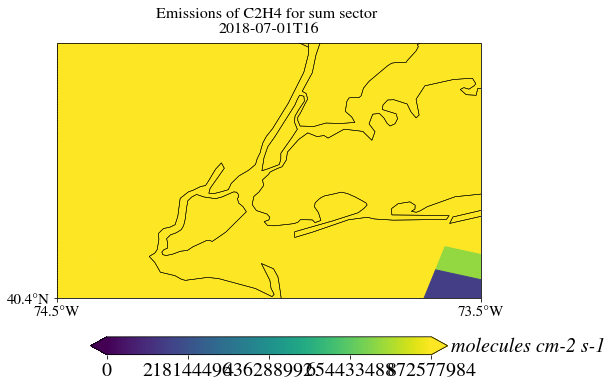

In [153]:
# Quick plot to check

Timei = '2018-07-01T16:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'NYC'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

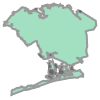

In [112]:
geom

In [113]:
# Create a mask for the dataset
mask = np.zeros(len(lat), dtype=bool)

# Iterate over the geometries and update the mask
points_within_bounds = []
for geom in gdf['geometry']:
    for i in range(len(lat)):
        point = Point(Adjustedlons[i], lat[i])
        if geom.contains(point):
            points_within_bounds.append((Adjustedlons[i], lat[i]))
            mask[i] = True


In [114]:
points_within_bounds

[(-73.92513090644587, 40.66777438139977),
 (-74.17550835478971, 40.61821030175612),
 (-74.21332749807624, 40.5234345875208),
 (-73.86310056573143, 40.82081824630117),
 (-73.79397435750764, 40.63964531158198)]

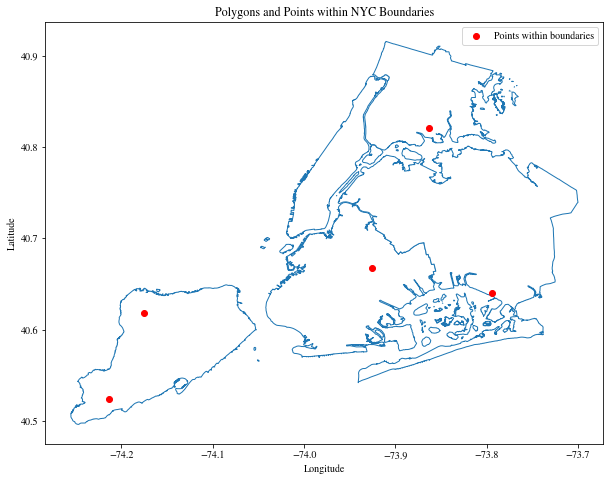

In [129]:
# Plot the GeoDataFrame (polygons)
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='white', edgecolor='tab:blue')

# Plot the points within the boundaries
points_within_bounds = np.array(points_within_bounds)
ax.scatter(points_within_bounds[:, 0], points_within_bounds[:, 1], color='red', marker='o', label='Points within boundaries')

# Customize the plot
ax.set_title('Polygons and Points within NYC Boundaries')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

# Show the plot
plt.show()


In [123]:
# Convert mask to DataArray
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Apply the mask to the dataset
masked_ds = spci_ds.where(mask_da, drop=True)

# Apply the mask to the 'sum' variable
sum_masked = spci_ds['sum'].where(~mask_da, other=np.nan)

In [144]:
spci_ds

<xarray.Dataset>
Dimensions:       (time: 913, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 2018-06-29 ... 2018-08-06
  * ncol          (ncol) float64 0.0 1.0 2.0 ... 1.741e+05 1.741e+05 1.741e+05
Data variables:
    lon           (ncol) float64 234.4 234.7 235.4 235.8 ... 299.0 299.5 299.3
    lat           (ncol) float64 6.166 6.049 5.86 5.742 ... 47.22 47.31 47.14
    area          (ncol) float64 ...
    rrfac         (ncol) float64 ...
    date          (time) int32 ...
    sum           (time, ncol) float32 7.905e+03 1.071e+04 ... 3.494e+06
    Adjustedlons  (ncol) float64 -125.6 -125.3 -124.6 ... -61.01 -60.51 -60.71
Attributes: (12/28)
    Conventions:                          CF-1.6
    citation:                             Elguindi, N., Granier, C., Stavrako...
    projection:                           latlon
    title:                                CAMS Global anthropogenic emissions
    references:                           Elguindi, N., Granier, C., Stavrako...
    authors:                              A.Soulie and C.Granier
    ...                                   ...
    remmaped_from_files:                  from file(s): /net/fs06/d2/taoma528...
    mapping_equation:                     C2H4[28]     = 1.0*ethene          ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2023-11-14 10:12:07.042435
    remmaping_username:                   taoma528 on fs06.inband
    comment_from_Species_Mapping_script:

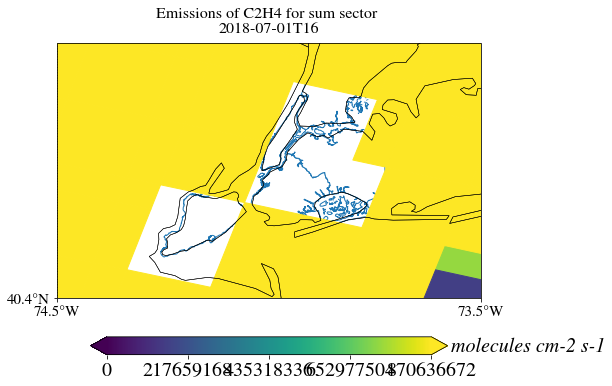

In [143]:
# Quick plot to check

Timei = '2018-07-01T16:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'NYC'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = sum_masked.sel(time=Timei).values#*scalefactor
Plot_unit = sum_masked.sel(time=Timei).units#+' ('+formatted_label+')'
longname = sum_masked.sel(time=Timei).long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())

gdf.plot(ax=ax1, color='white', edgecolor='tab:blue')

if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 
    
# finish plotting

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [154]:
# Convert mask to DataArray
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Apply the mask to the dataset
masked_ds = spci_ds.where(mask_da, drop=True)

# Apply the mask to the 'sum' variable
sum_masked = spci_ds['sum'].where(~mask_da, other=np.nan)

spci_ds['sum'] = sum_masked

In [156]:
spci_ds

<xarray.Dataset>
Dimensions:       (time: 913, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 2018-06-29 ... 2018-08-06
  * ncol          (ncol) float64 0.0 1.0 2.0 ... 1.741e+05 1.741e+05 1.741e+05
Data variables:
    lon           (ncol) float64 234.4 234.7 235.4 235.8 ... 299.0 299.5 299.3
    lat           (ncol) float64 6.166 6.049 5.86 5.742 ... 47.22 47.31 47.14
    area          (ncol) float64 ...
    rrfac         (ncol) float64 ...
    date          (time) int32 ...
    sum           (time, ncol) float32 7.905e+03 1.071e+04 ... 3.494e+06
    Adjustedlons  (ncol) float64 -125.6 -125.3 -124.6 ... -61.01 -60.51 -60.71
Attributes: (12/28)
    Conventions:                          CF-1.6
    citation:                             Elguindi, N., Granier, C., Stavrako...
    projection:                           latlon
    title:                                CAMS Global anthropogenic emissions
    references:                           Elguindi, N., Granier, C., Stavrako...
    authors:                              A.Soulie and C.Granier
    ...                                   ...
    remmaped_from_files:                  from file(s): /net/fs06/d2/taoma528...
    mapping_equation:                     C2H4[28]     = 1.0*ethene          ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2023-11-14 10:12:07.042435
    remmaping_username:                   taoma528 on fs06.inband
    comment_from_Species_Mapping_script:

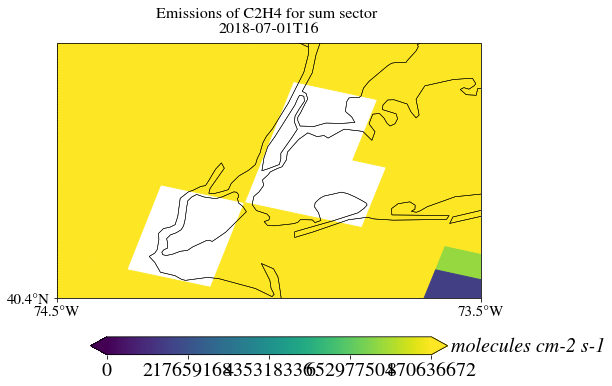

In [155]:
# Quick plot to check

Timei = '2018-07-01T16:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'NYC'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

## Plot to Check processed dataspci

In [39]:
spci_filename = '/net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/NYCMasked_MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_CH3COCH3_c20231113.nc'
spci_ds = xr.open_dataset(spci_filename)
spci_ds

<xarray.Dataset>
Dimensions:  (time: 913, ncol: 174098)
Coordinates:
  * time     (time) datetime64[ns] 2018-06-29 2018-06-29T01:00:00 ... 2018-08-06
  * ncol     (ncol) float64 0.0 1.0 2.0 3.0 ... 1.741e+05 1.741e+05 1.741e+05
Data variables:
    lon      (ncol) float64 ...
    lat      (ncol) float64 ...
    area     (ncol) float64 ...
    rrfac    (ncol) float64 ...
    date     (time) int32 ...
    sum      (time, ncol) float32 ...
Attributes: (12/28)
    Conventions:                          CF-1.6
    citation:                             Elguindi, N., Granier, C., Stavrako...
    projection:                           latlon
    title:                                CAMS Global anthropogenic emissions
    references:                           Elguindi, N., Granier, C., Stavrako...
    authors:                              A.Soulie and C.Granier
    ...                                   ...
    remmaped_from_files:                  from file(s): /net/fs06/d2/taoma528...
    mapping_equation:                     CH3COCH3[58] = 0.2*ketones         ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2023-11-14 10:12:25.512562
    remmaping_username:                   taoma528 on fs06.inband
    comment_from_Species_Mapping_script:

In [25]:
spci_ds['sum'].values

array([[ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194490.  ,
        1293456.8 ],
       [ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194146.  ,
        1126402.6 ],
       [ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194061.  ,
        1076744.1 ],
       ...,
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9743148.  ,
        1420025.1 ],
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9741908.  ,
         827617.3 ],
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9815688.  ,
        1093985.9 ]], dtype=float32)

In [49]:
hourlyNEI_diri

'/net/fs06/d2/taoma528/CESM22/CAMS_withCONUS2017NEI/MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/'

In [23]:
spci_filename = f'{hourlyNEI_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_SVOC_c20231113.nc'
orgspci_ds = xr.open_dataset(spci_filename)
orgspci_ds

<xarray.Dataset>
Dimensions:  (time: 913, ncol: 174098)
Coordinates:
  * time     (time) datetime64[ns] 2018-06-29 2018-06-29T01:00:00 ... 2018-08-06
  * ncol     (ncol) float64 0.0 1.0 2.0 3.0 ... 1.741e+05 1.741e+05 1.741e+05
Data variables:
    lon      (ncol) float64 ...
    lat      (ncol) float64 ...
    area     (ncol) float64 ...
    rrfac    (ncol) float64 ...
    date     (time) int32 ...
    sum      (time, ncol) float32 ...
Attributes: (12/27)
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              A.Soulie and C.Granier
    product_version:                      v5.1
    title:                                CAMS Global anthropogenic emissions
    source:                               EDGARv5 emissions up to 2015, CAMS-...
    ...                                   ...
    remmaped_from_files:                  from file(s): /net/fs06/d2/taoma528...
    mapping_equation:                     SVOC[310]    = 0.6*1.4*oc          ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2023-11-14 10:12:32.662176
    remmaping_username:                   taoma528 on fs06.inband
    comment_from_Species_Mapping_script:

In [26]:
orgspci_ds['sum'].values

array([[ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194490.  ,
        1293456.8 ],
       [ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194146.  ,
        1126402.6 ],
       [ 915671.9 ,  777729.25,  196043.47, ...,  850304.3 , 9194061.  ,
        1076744.1 ],
       ...,
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9743148.  ,
        1420025.1 ],
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9741908.  ,
         827617.3 ],
       [  29929.26,   85358.37,  129180.03, ...,  247511.06, 9815688.  ,
        1093985.9 ]], dtype=float32)

132247336.0

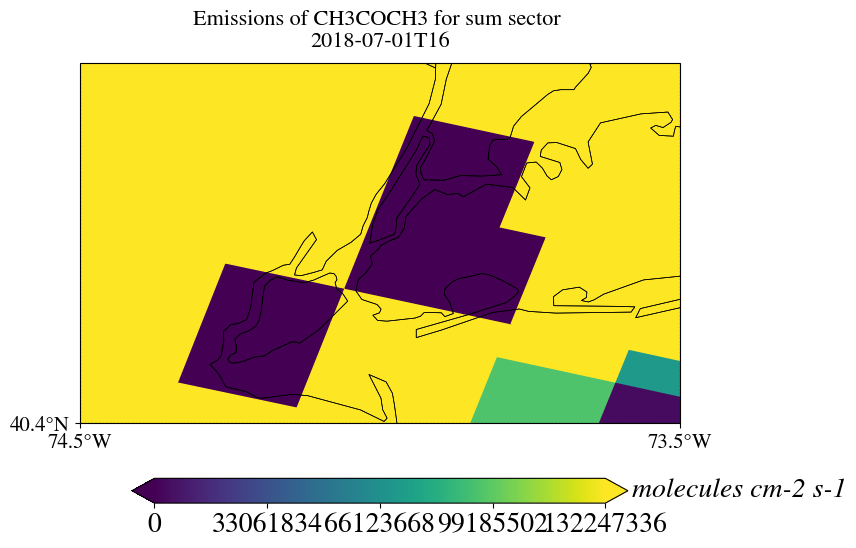

In [40]:
# Quick plot to check

Timei = '2018-07-01T16:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'NYC'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

np.nanmean(Plot_ar)

In [60]:
np.nanmean(spci_ds.sel(time='2018-07-07T19:00:00.000000000')['sum'].values)-np.nanmean(spci_ds.sel(time='2018-07-01T19:00:00.000000000')['sum'].values)

-2656832.0

In [33]:
np.nanmean(spci_ds.sel(time='2018-07-07T19:00:00.000000000')['sum'].values)-np.nanmean(spci_ds.sel(time='2018-07-01T19:00:00.000000000')['sum'].values)

16485024.0

196811650.0

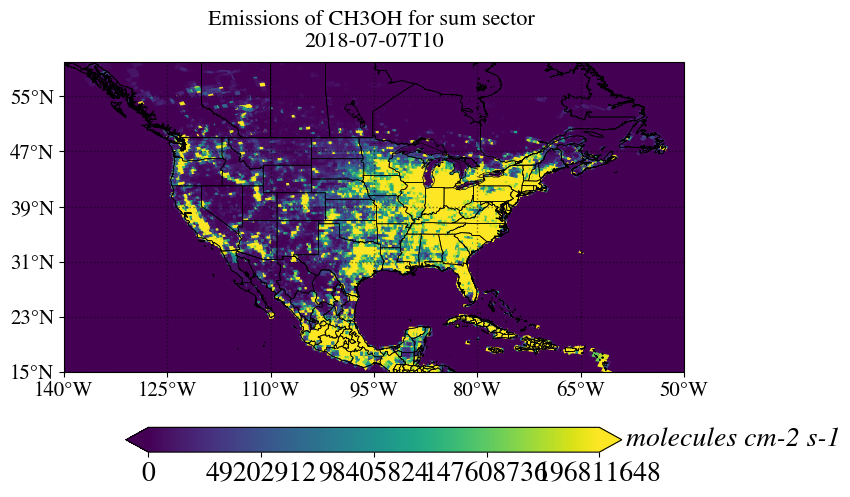

In [35]:
# Quick plot to check

Timei = '2018-07-07T10:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

# Plot_ar = spci_ds.sel(time='2018-07-07T19:00:00.000000000')['sum'].values-spci_ds.sel(time='2018-07-01T19:00:00.000000000')['sum'].values#*scalefactor
Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_CONUS, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

np.nanmean(Plot_ar)

# Estimate CONUS Emissions (numbers replaced with zero)

In [7]:
### Read in NEI emissions data
hourlyNEI_diri = '/net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8/'
# JulyMeanNEI_diri = '/net/fs09/d0/taoma528/CESM22/CAMS_withCONUS2017NEI/MappedSpecies_GLOB_Merged_CAMS_NEI_ne0CONUSne30x8_JulyMean/'

# get a list of species name I have updated 
MappedSpecies_dir = hourlyNEI_diri
DateOfModify = 'c20231113' #'c20231218';'c20231113'

# Search for files that match the pattern
pattern = '*NEI2017Merged_20181MJuly_CAMSv5.1*'+DateOfModify+'*'
Out_file_list = [file for file in glob.glob(os.path.join(MappedSpecies_dir, pattern)) if fnmatch.fnmatch(os.path.basename(file), pattern)]


In [8]:
len(Out_file_list)

updated_spcs = []

for fileidx in range(len(Out_file_list)):
    filename = Out_file_list[fileidx].split('/')[-1]
    # Find the starting and ending indexes for the species name
    start_index = filename.find('ne0CONUSne30x8_') + len('ne0CONUSne30x8_')
    end_index = filename.find(DateOfModify)
    # Extract the species name using the start and end indexes
    species_name = filename[start_index:end_index-1]
    # print(species_name) 
    updated_spcs.append(species_name)
    
print(f'Number of updated species: {len(updated_spcs)}')

Number of updated species: 25


In [9]:
### Estimate emissions within NYC boundary

import os
import numpy as np
import xarray as xr
from shapely.geometry import Point

# Define dictionary to store emission sums set to zero
city_emissions = {}

# Read in each file in the format 
# for spc in updated_spcs[:2]:
for spc in updated_spcs:
    # Construct file path
    FileInPath = f'{hourlyNEI_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_c20231113.nc'
    
    # Check if the file exists
    if not os.path.exists(FileInPath):
        print(f"{FileInPath} missing.")
        continue

    print(f'Calculating NYC-summed July mean emissions for {spc}')
    print('************************************************************************')

    # Open the dataset
    spci_ds = xr.open_dataset(FileInPath)

    # Adjust longitudes from 0-360 to -180 to 180
    lat = spci_ds['lat'].values
    lon = spci_ds['lon'].values
    Adjustedlons = np.where(lon >= 180, lon - 360, lon)
    Adjustedlons_da = xr.DataArray(Adjustedlons, dims=('ncol'), coords={'ncol': spci_ds.ncol.values})
    spci_ds['Adjustedlons'] = Adjustedlons_da

    # Create a mask based on the boundary geometry
    mask = np.zeros(len(lat), dtype=bool)
    for geom in gdf['geometry']:
        for i in range(len(lat)):
            point = Point(Adjustedlons[i], lat[i])
            if geom.contains(point):
                mask[i] = True

    mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

    # Initialize dictionary for this city and species if not already created
    if spc not in city_emissions:
        city_emissions[spc] = {}

    # Iterate over variables except those to ignore, apply mask, set to 0, and calculate sum
    excluded_vars = ['lon', 'lat', 'area', 'rrfac', 'date', 'Adjustedlons']
    for var_name in spci_ds.data_vars:
        if var_name not in excluded_vars:
            print(var_name)
            # Set emissions to zero within the boundary
            zeroed_emissions = spci_ds[var_name].where(~mask_da, other=0)
            
            # Calculate sum of emissions that were set to zero
            sum_Cityi_emissions = spci_ds[var_name].where(mask_da).sum().item() # use .item() to get just the number

            # Store the result in the dictionary
            if var_name not in city_emissions[spc]:
                city_emissions[spc][var_name] = sum_Cityi_emissions
                # add unit information
                city_emissions[spc]["unites"] = spci_ds["sum"].units

    print('************************************************************************')



Calculating NYC-summed July mean emissions for CH3OH
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for num_pom_a4
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for NH3
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for BIGENE
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for TOLUENE
************************************************************************
sum
****************************************************

In [10]:
# Flatten the dictionary to create a DataFrame with separate columns for sum and units
flattened_data = {
    species: {'sum': details['sum'], 'units': details['unites']}
    for species, details in city_emissions.items()
}

# Convert to DataFrame
emissions_df = pd.DataFrame(flattened_data).T

# Format the 'sum' column in scientific notation with 2 decimal places
emissions_df['sum'] = emissions_df['sum'].apply(lambda x: f"{x:.2e}")

emissions_df

,sum,units
CH3OH,2.05e+14,molecules cm-2 s-1
num_pom_a4,3.21e+33,(particles cm-2 s-1)(molecules mole-1)(g kg-1)
NH3,4.05e+14,molecules cm-2 s-1
BIGENE,1.49e+14,molecules cm-2 s-1
TOLUENE,2.57e+14,molecules cm-2 s-1
C3H8,1.78e+14,molecules cm-2 s-1
pom_a4,2.49e+15,molecules cm-2 s-1
bc_a4,4.53e+14,molecules cm-2 s-1
ISOP,2.20e+12,molecules cm-2 s-1
BENZENE,4.74e+13,molecules cm-2 s-1


In [11]:
# Export the DataFrame to CSV
csv_path = "./NYCsummed_JulyMean_AnthroEmis.csv"
emissions_df.to_csv(csv_path)

print("Saved to:", csv_path)

Saved to: ./NYCsummed_JulyMean_AnthroEmis.csv


#### Draft checking calculations

In [33]:
city_emissions

{'CH3OH': {'sum': 204575634096128.0},
 'num_pom_a4': {'sum': 3.2058617522663475e+33}}

In [25]:
zeroed_emissions.sum()

<xarray.DataArray 'sum' ()>
array(4.996124e+16, dtype=float32)

In [21]:
var_name = 'sum'

In [27]:
spci_ds[var_name].sum().item()

5.016578924793037e+16

In [22]:
spci_ds[var_name].where(mask_da).sum()

<xarray.DataArray 'sum' ()>
array(2.0457563e+14, dtype=float32)

In [26]:
zeroed_emissions.sum()+spci_ds[var_name].where(mask_da).sum()

<xarray.DataArray 'sum' ()>
array(5.0165815e+16, dtype=float32)

In [ ]:
['lon','lat','area','rrfac','date','Adjustedlons']

# Analyze Output Simulations